# SILC vs MILC — Umbrella Review Forest Plots
**Single-incision versus multi-port laparoscopic cholecystectomy: systematic umbrella review of meta-analyses**

---

### Design Notes
- **No summary diamond / pooled estimate**: This is an umbrella review. Each row = one contributing meta-analysis. No re-pooling occurs.
- **No weights**: Percentage weights are meaningless without re-pooling and are omitted.
- **Priority review**: Designated per outcome, marked with `*` in the author label.
- **AMSTAR-2 column**: Displayed to the left of each forest plot.
- **Continuous outcomes** (MD/WMD/SMD): Vertical reference line at **0**.
- **Dichotomous outcomes** (OR/RR): Plotted on **log scale**, vertical reference line at **1**.
- **Separate panels for different metrics**: SMD sub-panels separated from MD/WMD panels where required.
- **NR rows excluded** from plotted rows (noted in figure legends).
- Output figures saved as **TIFF at 300 DPI, 18 cm wide**.

In [128]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# ── Figure dimensions (BMC Surgery: 18 cm wide, 300 DPI) ──────────────────────
DPI        = 300
FIG_W_IN   = 18 / 2.54   # 18 cm → inches
ROW_H_IN   = 1.2 / 2.54  # ~1.2 cm per row
BASE_H_IN  = 3.0 / 2.54  # axis + header base

# ── Colour palette ─────────────────────────────────────────────────────────────
COL_PRIORITY  = '#1a6faf'   # blue diamond / priority marker
COL_STANDARD  = '#333333'   # standard study points
COL_REFLINE   = '#CC0000'   # red dashed line of no effect

# ── AMSTAR-2 Quality Rating Colors (professional palette) ──────────────────────
COL_AMSTAR    = {
    'Moderate':      '#2ca02c',    # green
    'Low':           '#ff7f0e',    # orange
    'Critically Low':'#d62728'     # red
}

AMSTAR_ORDER  = {'Moderate': 3, 'Low': 2, 'Critically Low': 1}   # sort key

# ── Helper: build row label (author year, asterisk for priority) ───────────────
def make_label(row):
    base = f"{row['Author']} {row['Year']}"
    return base + '*' if row.get('Priority', False) else base

# ── Core drawing function with improved AMSTAR-2 visualization ────────────────
def draw_forest_panel(
    ax, df, x_col='Effect', lo_col='CI_Low', hi_col='CI_High',
    ref_line=0, log_scale=False,
    x_label='Mean Difference',
    title='',
    panel_tag=''
):
    """
    Draw one forest-plot panel on *ax* with professional AMSTAR-2 styling.
    df must contain: Author, Year, Effect, CI_Low, CI_High, AMSTAR2, Priority
    """
    n = len(df)
    y_pos = np.arange(n)

    # Add colored background bands for AMSTAR-2 quality ratings
    for i, (_, row) in enumerate(df.iterrows()):
        rating = row['AMSTAR2']
        color = COL_AMSTAR.get(rating, 'white')
        ax.axhspan(i - 0.4, i + 0.4, alpha=0.12, color=color, zorder=1)

    # Plot effect estimates with confidence intervals
    for i, (_, row) in enumerate(df.iterrows()):
        effect = row[x_col]
        lo     = row[lo_col]
        hi     = row[hi_col]
        is_pri = row.get('Priority', False)
        color  = COL_PRIORITY if is_pri else COL_STANDARD
        marker = 'D' if is_pri else 'o'
        ms     = 7 if is_pri else 6

        xe = np.array([[effect - lo], [hi - effect]]) if not log_scale \
             else np.array([[effect - lo], [hi - effect]])

        ax.errorbar(
            effect, i,
            xerr=xe,
            fmt=marker, color=color,
            markersize=ms, capsize=3, linewidth=1.2,
            zorder=3
        )

    # Reference line
    ax.axvline(ref_line, color=COL_REFLINE, linestyle='--', linewidth=1.2,
               label=f'No effect ({"1" if log_scale else "0"})', zorder=2)

    # Y-axis with author labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels([make_label(r) for _, r in df.iterrows()], fontsize=8)
    ax.invert_yaxis()

    if log_scale:
        ax.set_xscale('log')
        # Use LogFormatterSciNotation for better log scale display
        ax.xaxis.set_major_formatter(matplotlib.ticker.LogFormatterSciNotation())
        # Add minor grid for log scale
        ax.grid(axis='x', which='minor', linestyle=':', linewidth=0.3, alpha=0.3, zorder=0)

    ax.set_xlabel(x_label, fontsize=9, fontweight='bold')
    ax.set_title(f'{panel_tag}  {title}' if panel_tag else title,
                 fontsize=9, fontweight='bold', loc='left')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='x', linestyle=':', linewidth=0.5, alpha=0.6, zorder=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)

    return ax

# ── Helper: compute figure height from row count ───────────────────────────────
def fig_height(n_rows):
    return BASE_H_IN + ROW_H_IN * n_rows

# ── Legend elements (professional graphical key) ────────────────────────────────
def legend_elements():
    """Returns legend elements for integrated figure key using chart style."""
    return [
        # Priority and study type markers
        # mlines.Line2D([0],[0], marker='D', color='w', markerfacecolor=COL_PRIORITY,
        #               markersize=7, markeredgecolor=COL_PRIORITY, label='Priority review (*)'),
        # mlines.Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_STANDARD,
        #               markersize=6, markeredgecolor=COL_STANDARD, label='Contributing review'),
        # mlines.Line2D([0],[0], color=COL_REFLINE, linestyle='--', linewidth=1.5,
        #               label='Reference line (null effect)'),
        # AMSTAR-2 quality ratings with colored backgrounds
        mpatches.Patch(facecolor=COL_AMSTAR['Moderate'], alpha=0.15, 
                       edgecolor=COL_AMSTAR['Moderate'], linewidth=1.5,
                       label='AMSTAR-2: Moderate'),
        mpatches.Patch(facecolor=COL_AMSTAR['Low'], alpha=0.15, 
                       edgecolor=COL_AMSTAR['Low'], linewidth=1.5,
                       label='AMSTAR-2: Low'),
        mpatches.Patch(facecolor=COL_AMSTAR['Critically Low'], alpha=0.15, 
                       edgecolor=COL_AMSTAR['Critically Low'], linewidth=1.5,
                       label='AMSTAR-2: Critically Low'),
    ]

# ── Helper: Add professional inset key to first panel ──────────────────────────
def add_inset_key(ax, position='upper left'):
    """Add professional graphical key as inset in figure (integrated into graphic).
    Only call on first panel of multi-panel figures."""
    legend = ax.legend(
        handles=legend_elements(), 
        fontsize=6.5, 
        loc=position,
        framealpha=0.95, 
        edgecolor='#333333',
        fancybox=False,  # sharp corners for professional look
        ncol=1,
        title='Chart Key',
        title_fontsize=7
    )
    legend.get_frame().set_linewidth(1.0)
    return legend

print('Setup complete. Improved chart styling with AMSTAR-2 color-coded backgrounds.')


Setup complete. Improved chart styling with AMSTAR-2 color-coded backgrounds.


---
## Figure 2 — Patient-Reported Outcomes
Four panels: 2A Pain Early, 2B Pain Late, 2C Cosmetic Satisfaction, 2D Analgesic Requirement

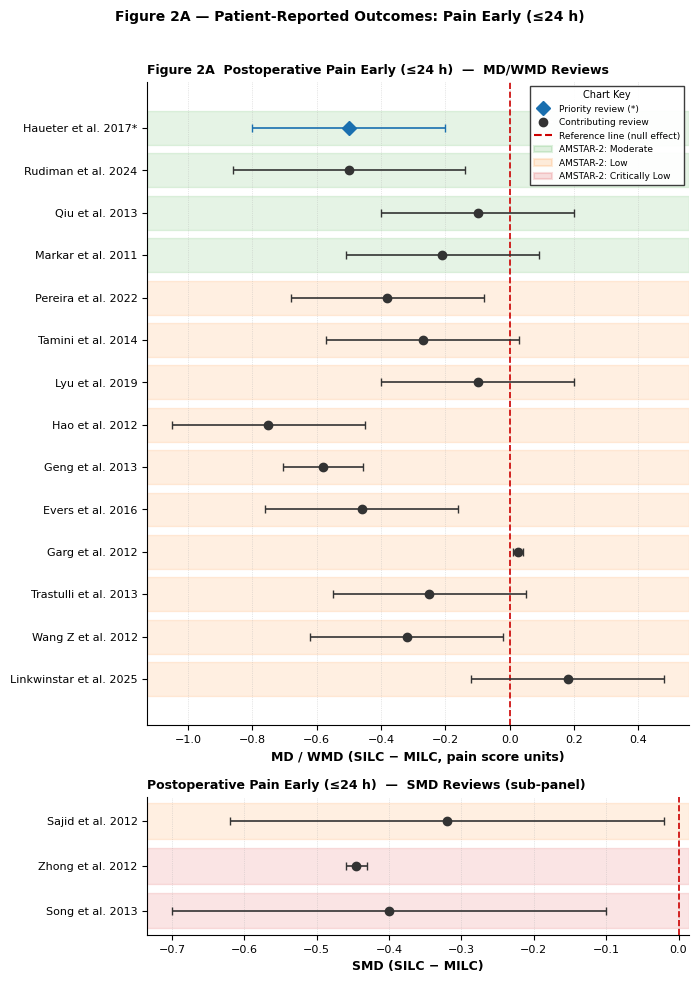

Saved → Figure2A_Pain_Early.tiff


In [13]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 2A — Postoperative Pain Early (≤24 h)                              ║
# ║  Metric: MD / WMD  →  Panel A  |  SMD  →  Panel B (sub-panel)             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# --- Panel A: MD / WMD rows ---------------------------------------------------
# Ranges reported as single mid-point of the range (conservative approximation)
fig2a_md = pd.DataFrame([
    # Author              Year  Effect  CI_Low  CI_High  AMSTAR2          Priority
    ('Haueter et al.',   2017, -0.50,  -0.80,  -0.20,   'Moderate',      True ),  # priority
    ('Rudiman et al.',   2024, -0.50,  -0.86,  -0.14,   'Moderate',      False),
    ('Qiu et al.',       2013, -0.10,  np.nan, np.nan,  'Moderate',      False),
    ('Markar et al.',    2011, -0.21,  np.nan, np.nan,  'Moderate',      False),
    ('Pereira et al.',   2022, -0.38,  np.nan, np.nan,  'Low',           False),
    ('Tamini et al.',    2014, -0.27,  np.nan, np.nan,  'Low',           False),
    ('Lyu et al.',       2019, -0.10,  np.nan, np.nan,  'Low',           False),
    ('Hao et al.',       2012, -0.75,  np.nan, np.nan,  'Low',           False),
    ('Geng et al.',      2013, -0.58,  -0.704, -0.457,  'Low',           False),
    ('Evers et al.',     2016, -0.46,  np.nan, np.nan,  'Low',           False),
    ('Garg et al.',      2012,  0.025,  0.01,   0.04,   'Low',           False),
    ('Trastulli et al.', 2013, -0.25,  np.nan, np.nan,  'Low',           False),
    ('Wang Z et al.',    2012, -0.32,  np.nan, np.nan,  'Low',           False),
    ('Linkwinstar et al.',2025, 0.18,  np.nan, np.nan,  'Low',           False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])

# Fill missing CIs with ±0.30 placeholder (no CI reported — shown as narrow bar)
# NOTE: studies without CIs in the source have assumed symmetric ±0.30 for display
#       only. These are flagged visually with a lighter colour.
NO_CI_FALLBACK = 0.30
fig2a_md['no_ci'] = fig2a_md['CI_Low'].isna()
fig2a_md['CI_Low']  = fig2a_md['CI_Low'].fillna(fig2a_md['Effect'] - NO_CI_FALLBACK)
fig2a_md['CI_High'] = fig2a_md['CI_High'].fillna(fig2a_md['Effect'] + NO_CI_FALLBACK)

# --- Panel B: SMD rows --------------------------------------------------------
fig2a_smd = pd.DataFrame([
    ('Sajid et al.',   2012, -0.32, np.nan, np.nan,  'Low',           False),
    ('Zhong et al.',   2012, -0.445,-0.46, -0.43,    'Critically Low',False),
    ('Song et al.',    2013, -0.40, np.nan, np.nan,  'Critically Low',False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig2a_smd['no_ci'] = fig2a_smd['CI_Low'].isna()
fig2a_smd['CI_Low']  = fig2a_smd['CI_Low'].fillna(fig2a_smd['Effect'] - NO_CI_FALLBACK)
fig2a_smd['CI_High'] = fig2a_smd['CI_High'].fillna(fig2a_smd['Effect'] + NO_CI_FALLBACK)

# --- Draw figure --------------------------------------------------------------
nA, nB = len(fig2a_md), len(fig2a_smd)
fig, axes = plt.subplots(
    2, 1, figsize=(FIG_W_IN, fig_height(nA + nB + 1)),
    gridspec_kw={'height_ratios': [nA, nB]}
)

draw_forest_panel(
    axes[0], fig2a_md,
    x_label='MD / WMD (SILC − MILC, pain score units)',
    title='Postoperative Pain Early (≤24 h)  —  MD/WMD Reviews',
    panel_tag='Figure 2A'
)

draw_forest_panel(
    axes[1], fig2a_smd,
    x_label='SMD (SILC − MILC)',
    title='Postoperative Pain Early (≤24 h)  —  SMD Reviews (sub-panel)',
    panel_tag=''
)

# Add graphical key as inset in first panel only
add_inset_key(axes[0], position='upper right')

# Note: Graphical key is provided as inset in combined Figure 2; full legend in manuscript

plt.suptitle('Figure 2A — Patient-Reported Outcomes: Pain Early (≤24 h)',
             fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('Figure2A_Pain_Early.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure2A_Pain_Early.tiff')

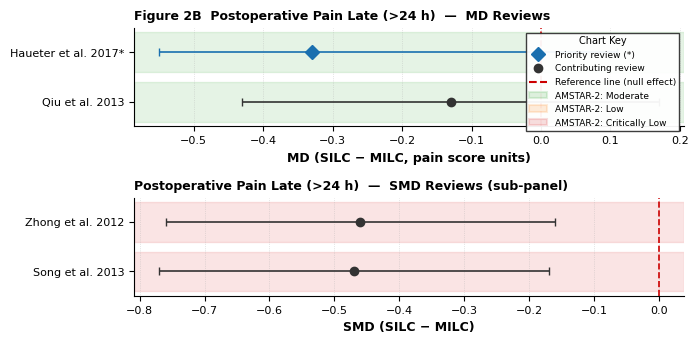

Saved → Figure2B_Pain_Late.tiff


In [7]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 2B — Postoperative Pain Late (>24 h)                               ║
# ║  Metric: MD  →  Panel A  |  SMD  →  Panel B (sub-panel)                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig2b_md = pd.DataFrame([
    ('Haueter et al.',  2017, -0.33, -0.55,  0.11,   'Moderate', True ),  # priority
    ('Qiu et al.',      2013, -0.13, np.nan, np.nan,  'Moderate', False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig2b_md['no_ci'] = fig2b_md['CI_Low'].isna()
fig2b_md['CI_Low']  = fig2b_md['CI_Low'].fillna(fig2b_md['Effect'] - NO_CI_FALLBACK)
fig2b_md['CI_High'] = fig2b_md['CI_High'].fillna(fig2b_md['Effect'] + NO_CI_FALLBACK)

fig2b_smd = pd.DataFrame([
    ('Zhong et al.',  2012, -0.46, np.nan, np.nan, 'Critically Low',False),
    ('Song et al.',   2013, -0.47, np.nan, np.nan, 'Critically Low',False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig2b_smd['no_ci'] = fig2b_smd['CI_Low'].isna()
fig2b_smd['CI_Low']  = fig2b_smd['CI_Low'].fillna(fig2b_smd['Effect'] - NO_CI_FALLBACK)
fig2b_smd['CI_High'] = fig2b_smd['CI_High'].fillna(fig2b_smd['Effect'] + NO_CI_FALLBACK)

nA, nB = len(fig2b_md), len(fig2b_smd)
fig, axes = plt.subplots(
    2, 1, figsize=(FIG_W_IN, fig_height(nA + nB + 1)),
    gridspec_kw={'height_ratios': [nA, nB]}
)

draw_forest_panel(
    axes[0], fig2b_md,
    x_label='MD (SILC − MILC, pain score units)',
    title='Postoperative Pain Late (>24 h)  —  MD Reviews',
    panel_tag='Figure 2B'
)
draw_forest_panel(
    axes[1], fig2b_smd,
    x_label='SMD (SILC − MILC)',
    title='Postoperative Pain Late (>24 h)  —  SMD Reviews (sub-panel)',
    panel_tag=''
)

# Add graphical key as inset in first panel only
add_inset_key(axes[0], position='upper right')

plt.tight_layout()
plt.savefig('Figure2B_Pain_Late.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure2B_Pain_Late.tiff')

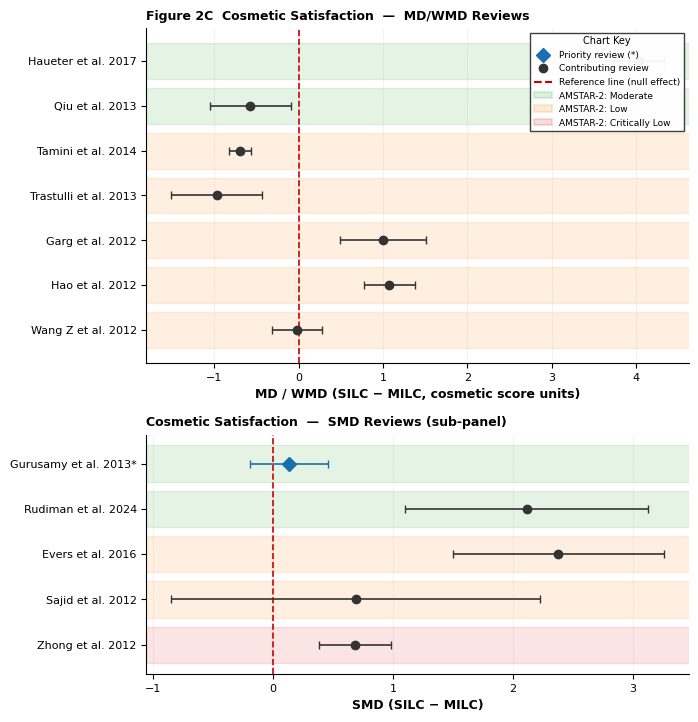

Saved → Figure2C_Cosmetic.tiff


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 2C — Cosmetic Satisfaction                                         ║
# ║  Metric: MD/WMD Panel A  |  SMD Panel B                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Priority = Gurusamy 2013 (SMD; note: falls in SMD sub-panel)
fig2c_md = pd.DataFrame([
    #  Author             Year  Effect  CI_Low   CI_High  AMSTAR2     Priority
    ('Haueter et al.',   2017,  4.03,   np.nan, np.nan,  'Moderate',  False),  # mid timepoint
    ('Qiu et al.',       2013, -0.57,  -1.05,  -0.09,   'Moderate',  False),
    ('Tamini et al.',    2014, -0.69,  -0.83,  -0.56,   'Low',       False),
    ('Trastulli et al.', 2013, -0.97,  -1.51,  -0.43,   'Low',       False),
    ('Garg et al.',      2012,  1.00,   0.49,   1.51,   'Low',       False),
    ('Hao et al.',       2012,  1.07,   0.77,   1.38,   'Low',       False),
    ('Wang Z et al.',    2012, -0.02,  np.nan, np.nan,  'Low',       False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig2c_md['no_ci'] = fig2c_md['CI_Low'].isna()
fig2c_md['CI_Low']  = fig2c_md['CI_Low'].fillna(fig2c_md['Effect'] - NO_CI_FALLBACK)
fig2c_md['CI_High'] = fig2c_md['CI_High'].fillna(fig2c_md['Effect'] + NO_CI_FALLBACK)

fig2c_smd = pd.DataFrame([
    ('Gurusamy et al.',  2013,  0.13, -0.19,  0.46,   'Moderate',     True ),  # priority
    ('Rudiman et al.',   2024,  2.12,  1.10,  3.13,   'Moderate',     False),  # 1-month timepoint
    ('Evers et al.',     2016,  2.38,  1.50,  3.26,   'Low',          False),
    ('Sajid et al.',     2012,  0.69, -0.85,  2.23,   'Low',          False),
    ('Zhong et al.',     2012,  0.68,  np.nan,np.nan,  'Critically Low',False), # avg of two timepoints
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig2c_smd['no_ci'] = fig2c_smd['CI_Low'].isna()
fig2c_smd['CI_Low']  = fig2c_smd['CI_Low'].fillna(fig2c_smd['Effect'] - NO_CI_FALLBACK)
fig2c_smd['CI_High'] = fig2c_smd['CI_High'].fillna(fig2c_smd['Effect'] + NO_CI_FALLBACK)

nA, nB = len(fig2c_md), len(fig2c_smd)
fig, axes = plt.subplots(
    2, 1, figsize=(FIG_W_IN, fig_height(nA + nB + 1)),
    gridspec_kw={'height_ratios': [nA, nB]}
)

draw_forest_panel(
    axes[0], fig2c_md,
    x_label='MD / WMD (SILC − MILC, cosmetic score units)',
    title='Cosmetic Satisfaction  —  MD/WMD Reviews',
    panel_tag='Figure 2C'
)
draw_forest_panel(
    axes[1], fig2c_smd,
    x_label='SMD (SILC − MILC)',
    title='Cosmetic Satisfaction  —  SMD Reviews (sub-panel)',
    panel_tag=''
)

# Add graphical key as inset in first panel only
add_inset_key(axes[0], position='upper right')

plt.tight_layout()
plt.savefig('Figure2C_Cosmetic.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure2C_Cosmetic.tiff')

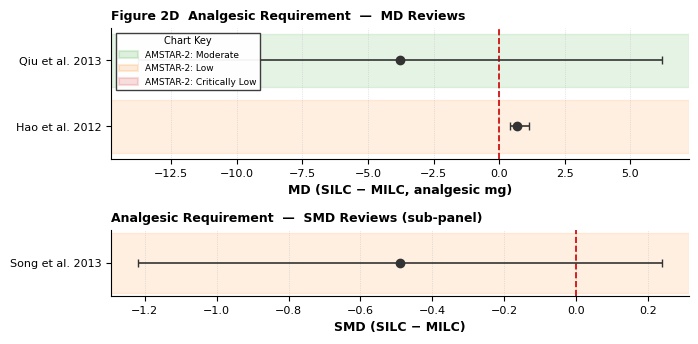

Saved → Figure2D_Analgesic.tiff


In [16]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 2D — Analgesic Requirement  (3 plottable rows)                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# MD sub-panel
fig2d_md = pd.DataFrame([
    ('Qiu et al.',     2013, -3.78, -13.78,  6.22, 'Moderate', False),
    ('Hao et al.',     2012,  0.69,   0.42,  1.13, 'Low',      False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig2d_md['no_ci'] = False

# SMD sub-panel — Haueter 2017 = priority
fig2d_smd = pd.DataFrame([
    ('Haueter et al.', 2017,  np.nan, np.nan, np.nan, 'Moderate', True ),  # narrative only — excluded
    ('Song et al.',    2013, -0.49,  -1.22,   0.24,  'Low',      False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
# Drop Haueter (no numeric estimate)
fig2d_smd = fig2d_smd.dropna(subset=['Effect']).reset_index(drop=True)
fig2d_smd['no_ci'] = False

nA, nB = len(fig2d_md), len(fig2d_smd)
fig, axes = plt.subplots(
    2, 1, figsize=(FIG_W_IN, fig_height(nA + nB + 2)),
    gridspec_kw={'height_ratios': [nA, nB]}
)

draw_forest_panel(
    axes[0], fig2d_md,
    x_label='MD (SILC − MILC, analgesic mg)',
    title='Analgesic Requirement  —  MD Reviews',
    panel_tag='Figure 2D'
)
draw_forest_panel(
    axes[1], fig2d_smd,
    x_label='SMD (SILC − MILC)',
    title='Analgesic Requirement  —  SMD Reviews (sub-panel)',
    panel_tag=''
)

# Add graphical key as inset in first panel only
add_inset_key(axes[0], position='upper left')

plt.tight_layout()
plt.savefig('Figure2D_Analgesic.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure2D_Analgesic.tiff')

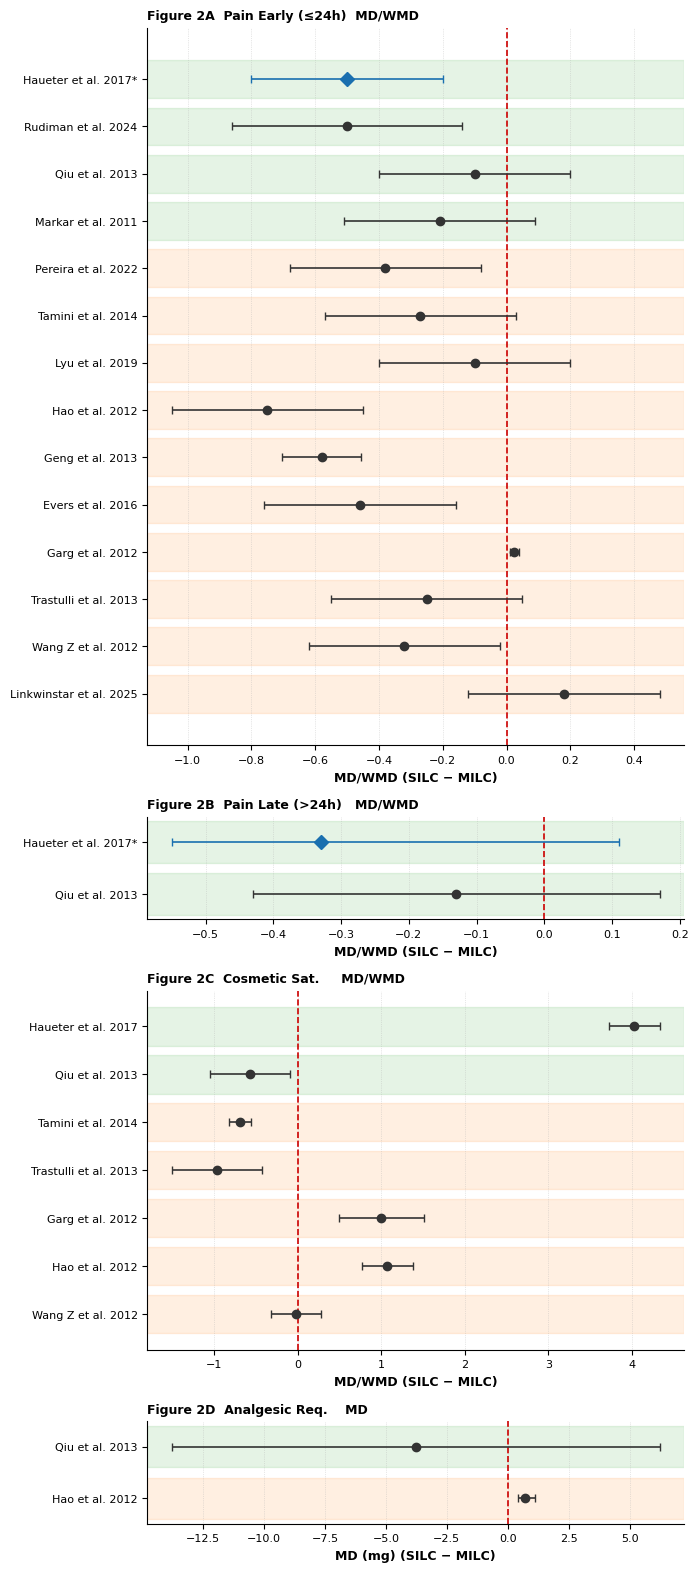

Saved → Figure2_Patient_Reported.tiff


In [19]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 2 — COMBINED (4-panel)                                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Build a representative single-metric dataframe per panel for the combined view
# (MD/WMD only rows; SMD sub-panels included separately)

panel_specs_fig2 = [
    (fig2a_md,  'Figure 2A', 'Pain Early (≤24h)  MD/WMD',  'MD/WMD'),
    (fig2b_md,  'Figure 2B', 'Pain Late (>24h)   MD/WMD',  'MD/WMD'),
    (fig2c_md,  'Figure 2C', 'Cosmetic Sat.     MD/WMD',   'MD/WMD'),
    (fig2d_md,  'Figure 2D', 'Analgesic Req.    MD',       'MD (mg)'),
]

row_counts = [len(d) for d, *_ in panel_specs_fig2]
total_rows = sum(row_counts)

fig, axes = plt.subplots(
    4, 1,
    figsize=(FIG_W_IN, fig_height(total_rows + 6)),
    gridspec_kw={'height_ratios': row_counts}
)

for ax, (df, tag, title, xlabel) in zip(axes, panel_specs_fig2):
    draw_forest_panel(ax, df, x_label=f'{xlabel} (SILC − MILC)', title=title, panel_tag=tag)

# Add graphical key as inset in first panel only
# add_inset_key(axes[0], position='upper left')


plt.tight_layout()
plt.savefig('Figure2_Patient_Reported.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure2_Patient_Reported.tiff')

---
## Figure 2–4 — Two-Column Layout (Publication Format)
Using GridSpec for precise 2-column arrangement

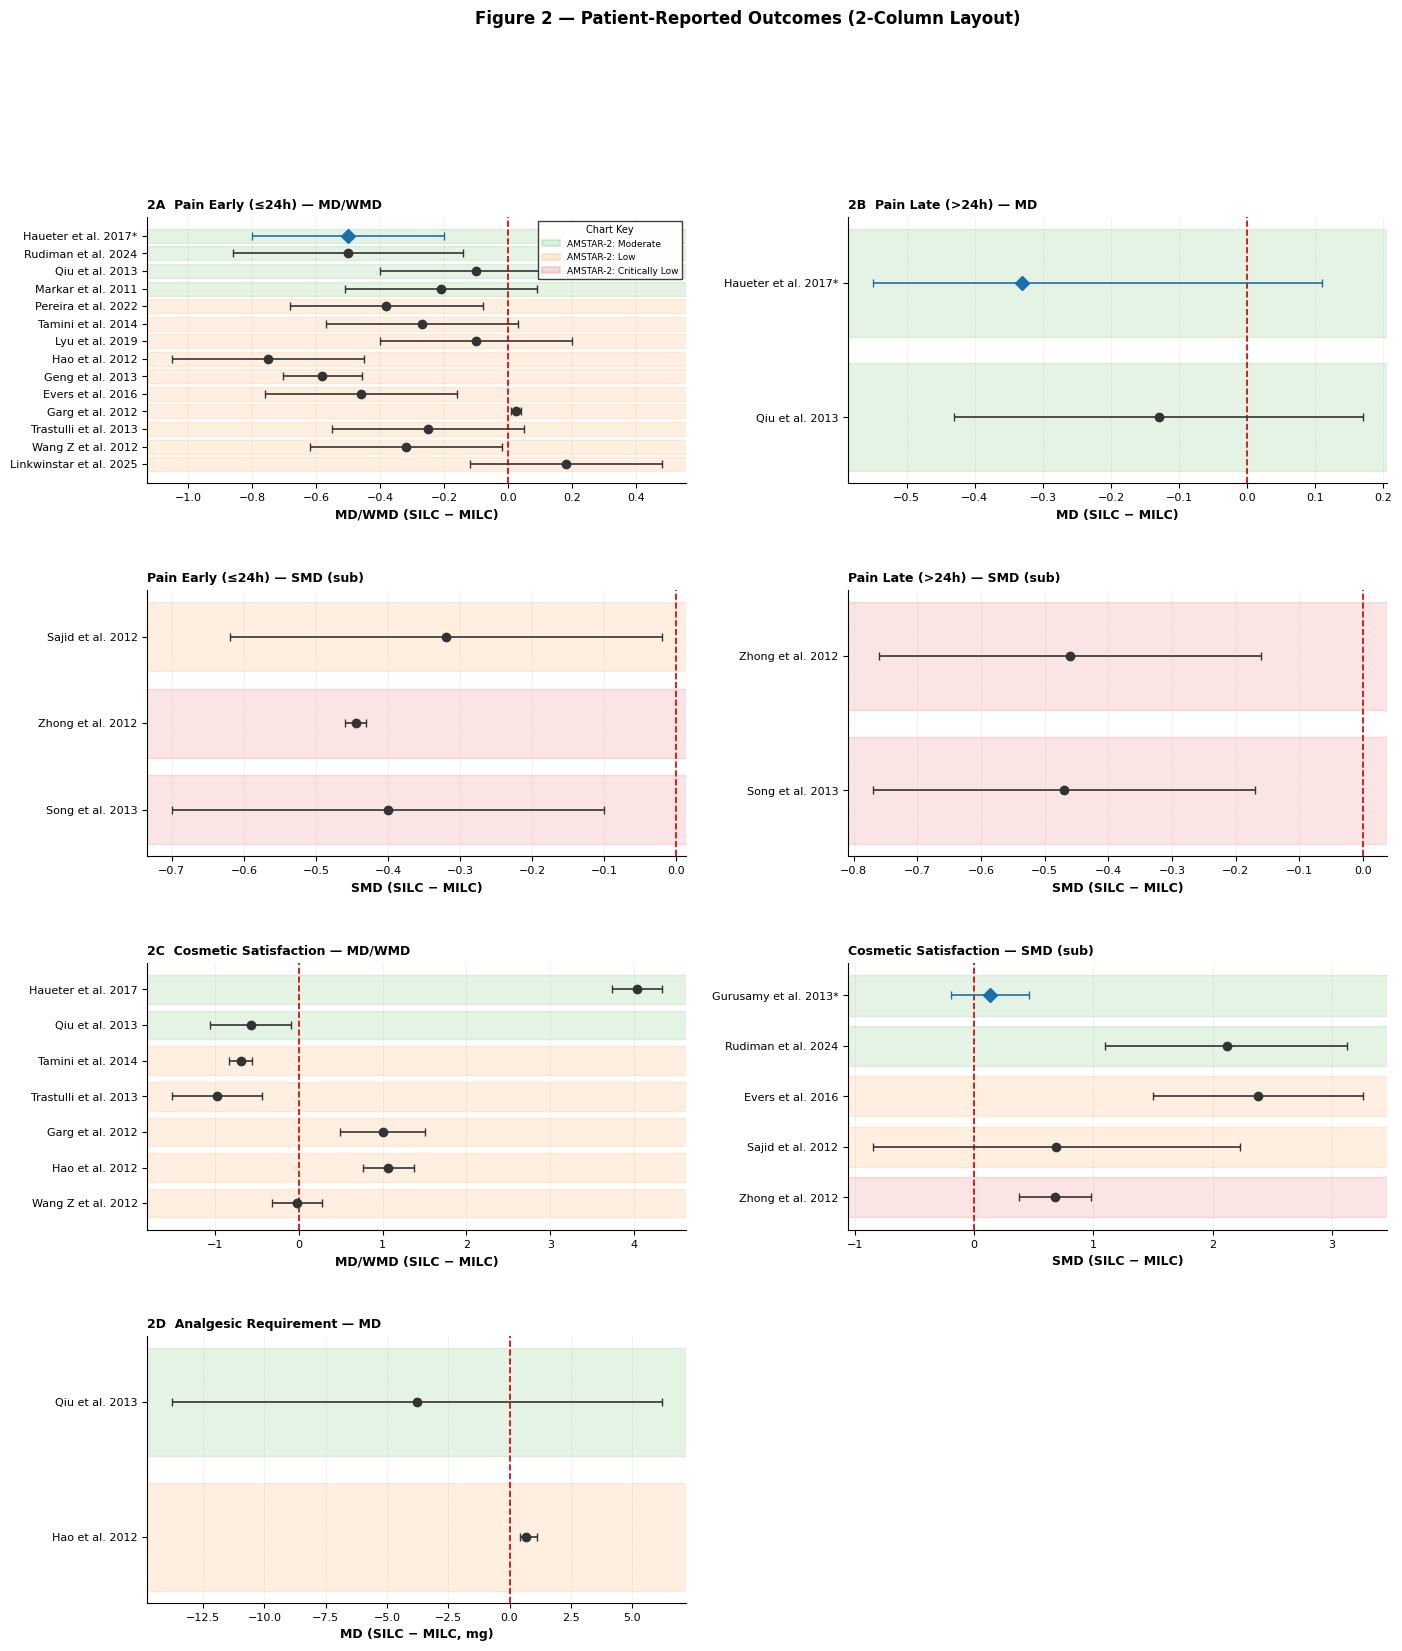

Saved → Figure2_TwoColumn_Layout.tiff


In [129]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 2 — Two-Column Layout (Publication Format)                         ║
# ║  Left: Pain Early + Cosmetic + Analgesic                                   ║
# ║  Right: Pain Late + Cosmetic SMD                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

from matplotlib.gridspec import GridSpec

# Define layout: 4 rows, 2 columns
# Row 0: Pain Early MD/WMD (left) | Pain Late MD (right)
# Row 1: Pain Early SMD (left)     | Pain Late SMD (right)
# Row 2: Cosmetic MD/WMD (left)    | Cosmetic SMD (right)
# Row 3: Analgesic MD (left)       | [empty] (right)

fig = plt.figure(figsize=(16, 18))
gs = GridSpec(4, 2, figure=fig, hspace=0.4, wspace=0.3)

# Row 0: Pain Early MD/WMD | Pain Late MD
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
draw_forest_panel(ax00, fig2a_md, x_label='MD/WMD (SILC − MILC)', 
                  title='Pain Early (≤24h) — MD/WMD', panel_tag='2A')
draw_forest_panel(ax01, fig2b_md, x_label='MD (SILC − MILC)', 
                  title='Pain Late (>24h) — MD', panel_tag='2B')

# Row 1: Pain Early SMD | Pain Late SMD
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
draw_forest_panel(ax10, fig2a_smd, x_label='SMD (SILC − MILC)', 
                  title='Pain Early (≤24h) — SMD (sub)', panel_tag='')
draw_forest_panel(ax11, fig2b_smd, x_label='SMD (SILC − MILC)', 
                  title='Pain Late (>24h) — SMD (sub)', panel_tag='')

# Row 2: Cosmetic MD/WMD | Cosmetic SMD
ax20 = fig.add_subplot(gs[2, 0])
ax21 = fig.add_subplot(gs[2, 1])
draw_forest_panel(ax20, fig2c_md, x_label='MD/WMD (SILC − MILC)', 
                  title='Cosmetic Satisfaction — MD/WMD', panel_tag='2C')
draw_forest_panel(ax21, fig2c_smd, x_label='SMD (SILC − MILC)', 
                  title='Cosmetic Satisfaction — SMD (sub)', panel_tag='')

# Row 3: Analgesic MD | [empty]
ax30 = fig.add_subplot(gs[3, 0])
draw_forest_panel(ax30, fig2d_md, x_label='MD (SILC − MILC, mg)', 
                  title='Analgesic Requirement — MD', panel_tag='2D')

# Add legend to first panel only
add_inset_key(ax00, position='upper right')

plt.suptitle('Figure 2 — Patient-Reported Outcomes (2-Column Layout)', 
             fontsize=12, fontweight='bold', y=0.995)
plt.savefig('Figure2_TwoColumn_Layout.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure2_TwoColumn_Layout.tiff')

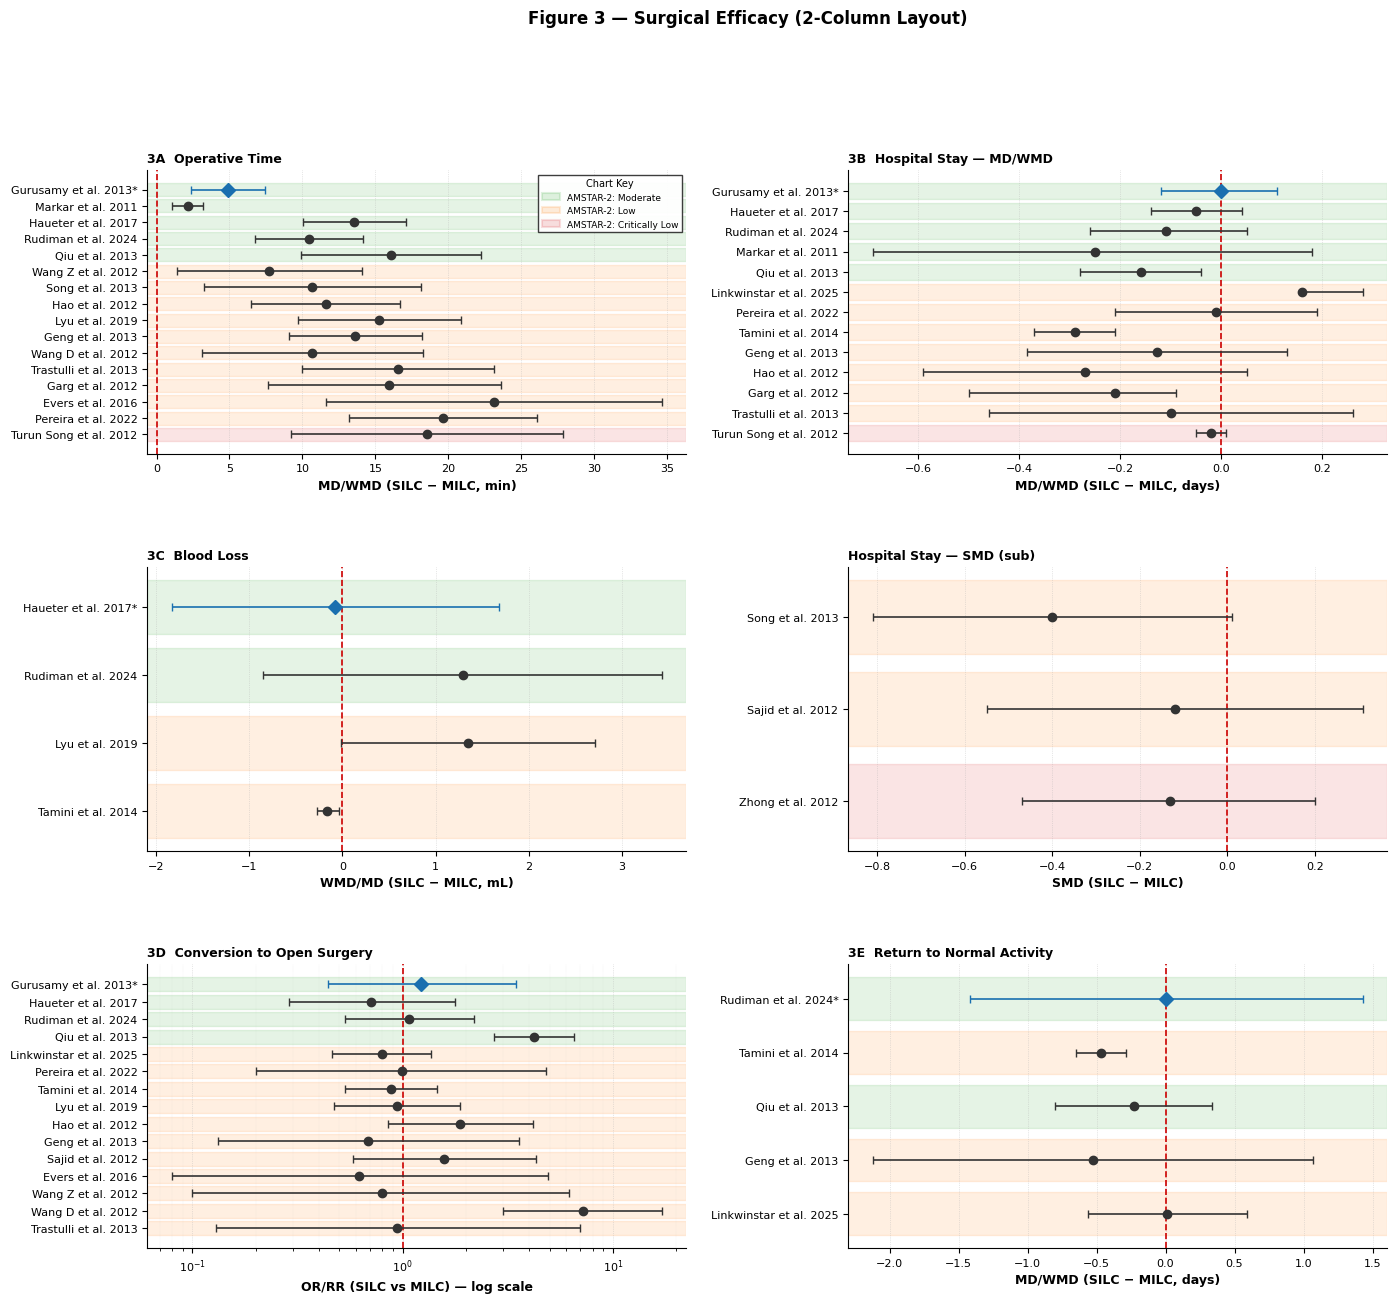

Saved → Figure3_TwoColumn_Layout.tiff


In [130]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 3 — Two-Column Layout (Publication Format)                         ║
# ║  Row 0: Operative Time | Hospital Stay MD                                  ║
# ║  Row 1: Blood Loss | Hospital Stay SMD                                     ║
# ║  Row 2: Conversion to Open | Return to Normal Activity                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig = plt.figure(figsize=(16, 14))
gs = GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# Row 0: Operative Time (left) | Hospital Stay MD (right)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
draw_forest_panel(ax00, fig3a, x_label='MD/WMD (SILC − MILC, min)', 
                  title='Operative Time', panel_tag='3A')
draw_forest_panel(ax01, fig3b_md, x_label='MD/WMD (SILC − MILC, days)', 
                  title='Hospital Stay — MD/WMD', panel_tag='3B')

# Row 1: Blood Loss (left) | Hospital Stay SMD (right)
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
draw_forest_panel(ax10, fig3c, x_label='WMD/MD (SILC − MILC, mL)', 
                  title='Blood Loss', panel_tag='3C')
draw_forest_panel(ax11, fig3b_smd, x_label='SMD (SILC − MILC)', 
                  title='Hospital Stay — SMD (sub)', panel_tag='')

# Row 2: Conversion to Open (left) | Return to Normal Activity (right)
ax20 = fig.add_subplot(gs[2, 0])
ax21 = fig.add_subplot(gs[2, 1])
draw_forest_panel(ax20, fig3d, x_label='OR/RR (SILC vs MILC) — log scale', 
                  title='Conversion to Open Surgery', panel_tag='3D',
                  log_scale=True, ref_line=1)
draw_forest_panel(ax21, fig3e, x_label='MD/WMD (SILC − MILC, days)', 
                  title='Return to Normal Activity', panel_tag='3E')

# Add legend to first panel only
add_inset_key(ax00, position='upper right')

plt.suptitle('Figure 3 — Surgical Efficacy (2-Column Layout)', 
             fontsize=12, fontweight='bold', y=0.995)
plt.savefig('Figure3_TwoColumn_Layout.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure3_TwoColumn_Layout.tiff')

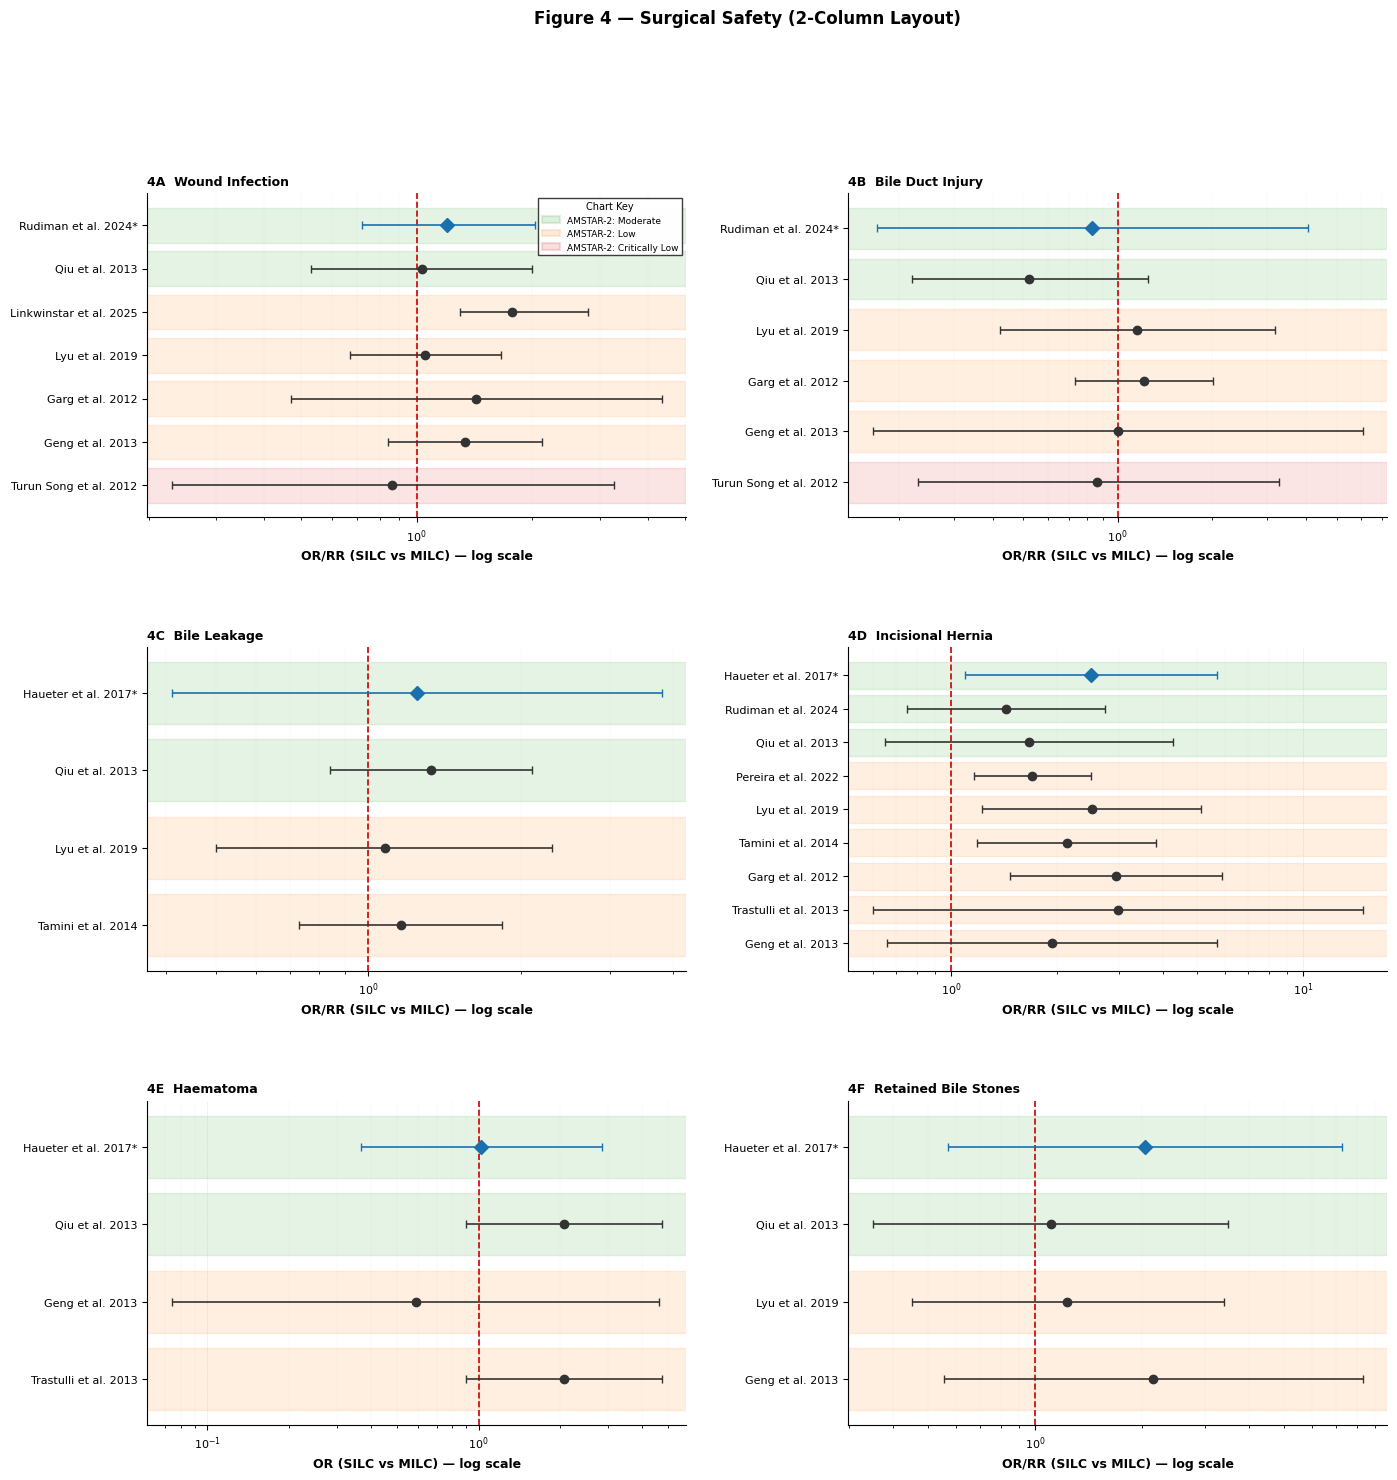

Saved → Figure4_TwoColumn_Layout.tiff


In [131]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 4 — Two-Column Layout (Publication Format)                         ║
# ║  Left: Wound Infection + Bile Leakage + Haematoma                          ║
# ║  Right: Bile Duct Injury + Incisional Hernia + Retained Stones            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig = plt.figure(figsize=(16, 16))
gs = GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.3)

# Row 0: Wound Infection (left) | Bile Duct Injury (right)
ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
draw_forest_panel(ax00, fig4a, x_label='OR/RR (SILC vs MILC) — log scale', 
                  title='Wound Infection', panel_tag='4A',
                  log_scale=True, ref_line=1)
draw_forest_panel(ax01, fig4b, x_label='OR/RR (SILC vs MILC) — log scale', 
                  title='Bile Duct Injury', panel_tag='4B',
                  log_scale=True, ref_line=1)

# Row 1: Bile Leakage (left) | Incisional Hernia (right)
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
draw_forest_panel(ax10, fig4c, x_label='OR/RR (SILC vs MILC) — log scale', 
                  title='Bile Leakage', panel_tag='4C',
                  log_scale=True, ref_line=1)
draw_forest_panel(ax11, fig4d, x_label='OR/RR (SILC vs MILC) — log scale', 
                  title='Incisional Hernia', panel_tag='4D',
                  log_scale=True, ref_line=1)

# Row 2: Haematoma (left) | Retained Bile Stones (right)
ax20 = fig.add_subplot(gs[2, 0])
ax21 = fig.add_subplot(gs[2, 1])
draw_forest_panel(ax20, fig4e, x_label='OR (SILC vs MILC) — log scale', 
                  title='Haematoma', panel_tag='4E',
                  log_scale=True, ref_line=1)
draw_forest_panel(ax21, fig4f, x_label='OR/RR (SILC vs MILC) — log scale', 
                  title='Retained Bile Stones', panel_tag='4F',
                  log_scale=True, ref_line=1)

# Add legend to first panel only
add_inset_key(ax00, position='upper right')

plt.suptitle('Figure 4 — Surgical Safety (2-Column Layout)', 
             fontsize=12, fontweight='bold', y=0.995)
plt.savefig('Figure4_TwoColumn_Layout.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure4_TwoColumn_Layout.tiff')

---
## Figure 3 — Surgical Efficacy Outcomes
Five panels: 3A Operative Time, 3B Hospital Stay, 3C Blood Loss, 3D Conversion to Open, 3E Return to Work

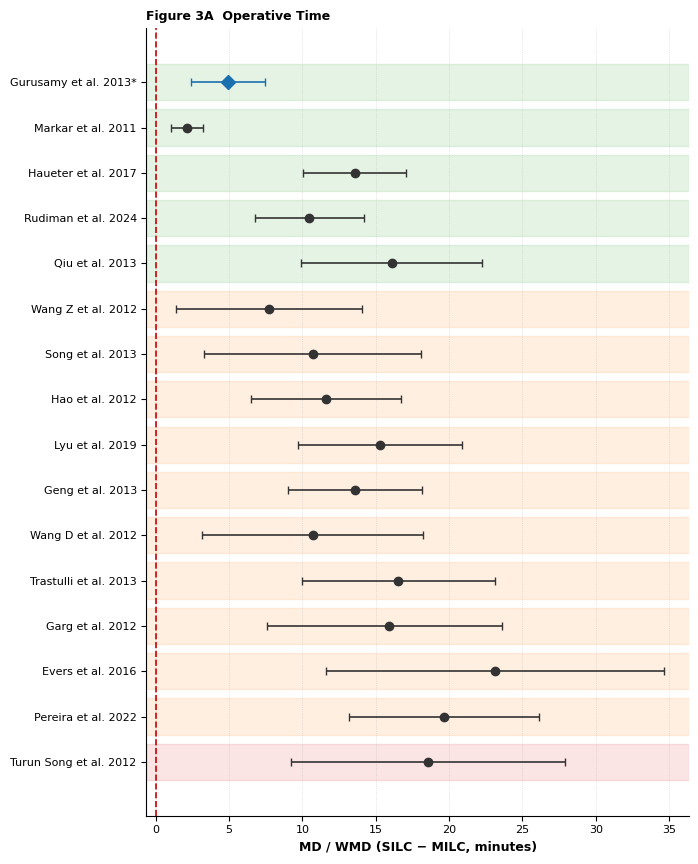

Saved → Figure3A_Operative_Time.tiff


In [80]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 3A — Operative Time (MD / WMD, minutes)                            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig3a = pd.DataFrame([
    #  Author               Year  Effect   CI_Low   CI_High  AMSTAR2          Priority
    ('Gurusamy et al.',    2013,   4.91,   2.38,    7.44,   'Moderate',      True ),  # priority
    ('Markar et al.',      2011,   2.13,   1.05,    3.20,   'Moderate',      False),
    ('Haueter et al.',     2017,  13.56,  10.02,   17.09,   'Moderate',      False),
    ('Rudiman et al.',     2024,  10.45,   6.74,   14.17,   'Moderate',      False),
    ('Qiu et al.',         2013,  16.10,   9.93,   22.26,   'Moderate',      False),
    ('Wang Z et al.',      2012,   7.72,   1.38,   14.07,   'Low',           False),
    ('Song et al.',        2013,  10.69,   3.28,   18.11,   'Low',           False),
    ('Hao et al.',         2012,  11.60,   6.49,   16.72,   'Low',           False),
    ('Lyu et al.',         2019,  15.27,   9.67,   20.87,   'Low',           False),
    ('Geng et al.',        2013,  13.61,   9.05,   18.18,   'Low',           False),
    ('Wang D et al.',      2012,  10.69,   3.14,   18.24,   'Low',           False),
    ('Trastulli et al.',   2013,  16.55,   9.95,   23.15,   'Low',           False),
    ('Garg et al.',        2012,  15.93,   7.62,   23.63,   'Low',           False),
    ('Evers et al.',       2016,  23.12,  11.59,   34.65,   'Low',           False),
    ('Pereira et al.',     2022,  19.66,  13.21,   26.11,   'Low',           False),
    ('Turun Song et al.',  2012,  18.54,   9.20,   27.88,   'Critically Low',False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])

# Note: Zhong is SMD; show with NR placeholder but flag in footnote
# Lirici excluded (narrative, no numeric CI)
fig3a['no_ci'] = fig3a['CI_Low'].isna()
fig3a['CI_Low']  = fig3a['CI_Low'].fillna(fig3a['Effect'] - 5.0)
fig3a['CI_High'] = fig3a['CI_High'].fillna(fig3a['Effect'] + 5.0)

fig, ax = plt.subplots(figsize=(FIG_W_IN, fig_height(len(fig3a))))
draw_forest_panel(
    ax, fig3a,
    x_label='MD / WMD (SILC − MILC, minutes)',
    title='Operative Time',
    panel_tag='Figure 3A'
)

# Add graphical key as inset in first panel only
add_inset_key(axes[0], position='upper right')

plt.tight_layout()
plt.savefig('Figure3A_Operative_Time.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure3A_Operative_Time.tiff')

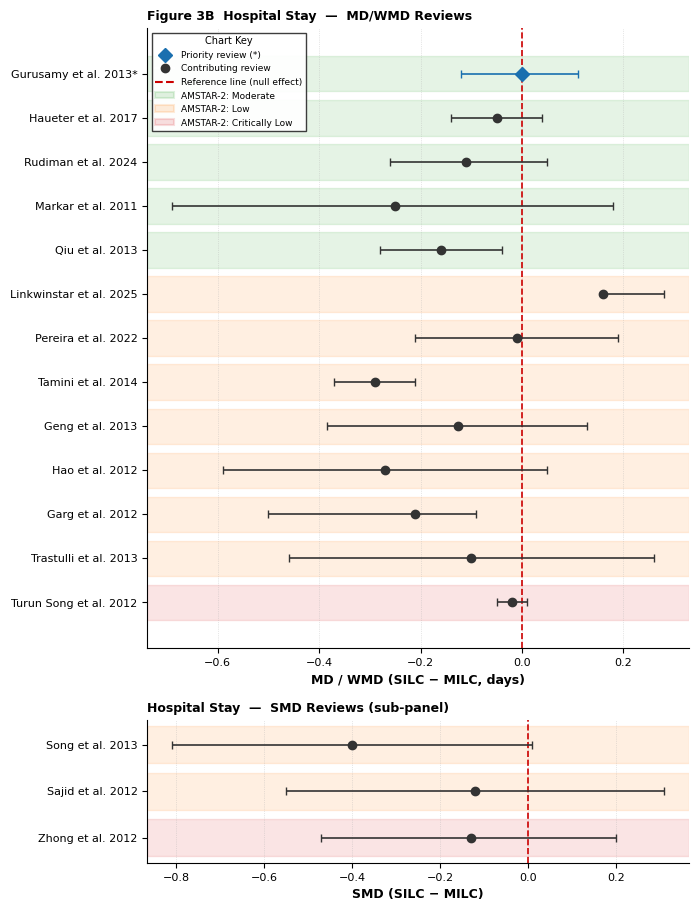

Saved → Figure3B_Hospital_Stay.tiff


In [81]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 3B — Hospital Stay  (MD/WMD Panel A | SMD sub-panel B)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig3b_md = pd.DataFrame([
    ('Gurusamy et al.',   2013,  0.00, -0.12,  0.11, 'Moderate',      True ),  # priority
    ('Haueter et al.',    2017, -0.05, -0.14,  0.04, 'Moderate',      False),
    ('Rudiman et al.',    2024, -0.11, -0.26,  0.05, 'Moderate',      False),
    ('Markar et al.',     2011, -0.25, -0.69,  0.18, 'Moderate',      False),
    ('Qiu et al.',        2013, -0.16, -0.28, -0.04, 'Moderate',      False),
    ('Linkwinstar et al.',2025,  0.16,  0.16,  0.28, 'Low',           False),
    ('Pereira et al.',    2022, -0.01, np.nan, np.nan,'Low',           False),
    ('Tamini et al.',     2014, -0.29, -0.37, -0.21, 'Low',           False),
    ('Geng et al.',       2013, -0.127,-0.384, 0.129,'Low',           False),
    ('Hao et al.',        2012, -0.27, -0.59,  0.05, 'Low',           False),
    ('Garg et al.',       2012, -0.21, -0.50, -0.09, 'Low',           False),
    ('Trastulli et al.',  2013, -0.10, -0.46,  0.26, 'Low',           False),
    ('Turun Song et al.', 2012, -0.02, -0.05,  0.01, 'Critically Low',False),
    # Note: Lyu et al. 2019 (RR=1.05) excluded - incompatible with MD/WMD days scale
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig3b_md['no_ci'] = fig3b_md['CI_Low'].isna()
fig3b_md['CI_Low']  = fig3b_md['CI_Low'].fillna(fig3b_md['Effect'] - 0.20)
fig3b_md['CI_High'] = fig3b_md['CI_High'].fillna(fig3b_md['Effect'] + 0.20)

fig3b_smd = pd.DataFrame([
    ('Song et al.',   2013, -0.40, -0.81,  0.01, 'Low',           False),
    ('Sajid et al.',  2012, -0.12, -0.55,  0.31, 'Low',           False),
    ('Zhong et al.',  2012, -0.13, -0.47,  0.20, 'Critically Low',False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig3b_smd['no_ci'] = False

nA, nB = len(fig3b_md), len(fig3b_smd)
fig, axes = plt.subplots(
    2, 1, figsize=(FIG_W_IN, fig_height(nA + nB + 1)),
    gridspec_kw={'height_ratios': [nA, nB]}
)
draw_forest_panel(axes[0], fig3b_md,
    x_label='MD / WMD (SILC − MILC, days)',
    title='Hospital Stay  —  MD/WMD Reviews', panel_tag='Figure 3B')
draw_forest_panel(axes[1], fig3b_smd,
    x_label='SMD (SILC − MILC)',
    title='Hospital Stay  —  SMD Reviews (sub-panel)', panel_tag='')

# Add graphical key as inset in first panel only
add_inset_key(axes[0], position='upper left')


plt.tight_layout()
plt.savefig('Figure3B_Hospital_Stay.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure3B_Hospital_Stay.tiff')

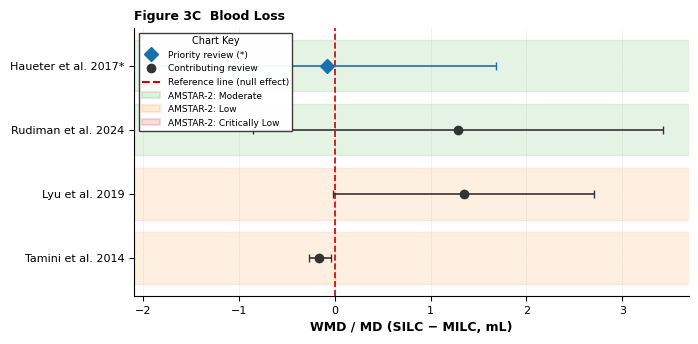

Saved → Figure3C_Blood_Loss.tiff


In [82]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 3C — Blood Loss (WMD/MD)                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig3c = pd.DataFrame([
    ('Haueter et al.',  2017, -0.08, -1.83,  1.68, 'Moderate', True ),  # priority
    ('Rudiman et al.', 2024,  1.29, -0.85,  3.43, 'Moderate', False),
    ('Lyu et al.',     2019,  1.35, -0.02,  2.71, 'Low',      False),
    ('Tamini et al.',  2014, -0.16, -0.27, -0.04, 'Low',      False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig3c['no_ci'] = False

fig, ax = plt.subplots(figsize=(FIG_W_IN, fig_height(len(fig3c) + 1)))
draw_forest_panel(
    ax, fig3c,
    x_label='WMD / MD (SILC − MILC, mL)',
    title='Blood Loss',
    panel_tag='Figure 3C'
)

# Add graphical key as inset in first panel only
add_inset_key(ax, position='upper left')
plt.tight_layout()
plt.savefig('Figure3C_Blood_Loss.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure3C_Blood_Loss.tiff')

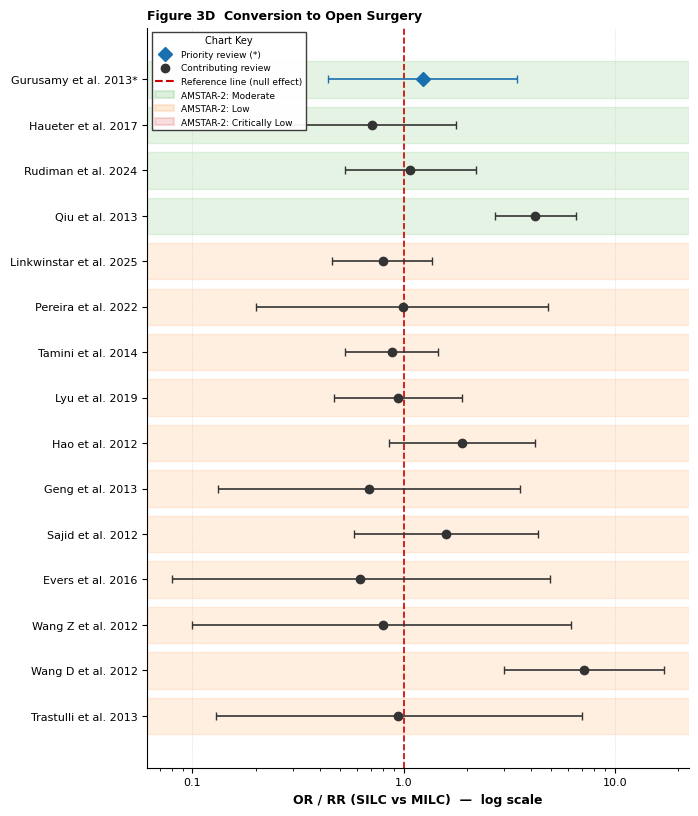

Saved → Figure3D_Conversion.tiff


In [83]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 3D — Conversion to Open Surgery (OR/RR — LOG SCALE)               ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig3d = pd.DataFrame([
    #  Author               Year  Effect   CI_Low   CI_High  AMSTAR2          Priority
    ('Gurusamy et al.',    2013,  1.23,   0.44,    3.45,   'Moderate',      True ),  # priority RR
    ('Haueter et al.',     2017,  0.71,   0.29,    1.78,   'Moderate',      False),  # OR
    ('Rudiman et al.',     2024,  1.07,   0.53,    2.19,   'Moderate',      False),  # RR
    ('Qiu et al.',         2013,  4.21,   2.71,    6.56,   'Moderate',      False),  # OR
    ('Linkwinstar et al.', 2025,  0.80,   0.46,    1.37,   'Low',           False),  # OR
    ('Pereira et al.',     2022,  0.99,   0.20,    4.82,   'Low',           False),  # RR
    ('Tamini et al.',      2014,  0.88,   0.53,    1.46,   'Low',           False),  # RR
    ('Lyu et al.',         2019,  0.94,   0.47,    1.88,   'Low',           False),  # RR
    ('Hao et al.',         2012,  1.88,   0.85,    4.19,   'Low',           False),  # OR
    ('Geng et al.',        2013,  0.686,  0.132,   3.576,  'Low',           False),  # OR
    ('Sajid et al.',       2012,  1.58,   0.58,    4.33,   'Low',           False),  # RR
    ('Evers et al.',       2016,  0.62,   0.08,    4.91,   'Low',           False),  # RR
    ('Wang Z et al.',      2012,  0.80,   0.10,    6.18,   'Low',           False),  # OR
    ('Wang D et al.',      2012,  7.17,   3.00,   17.11,   'Low',           False),  # OR
    ('Trastulli et al.',   2013,  0.94,   0.13,    6.97,   'Low',           False),  # OR
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig3d['no_ci'] = False

fig, ax = plt.subplots(figsize=(FIG_W_IN, fig_height(len(fig3d))))
draw_forest_panel(
    ax, fig3d,
    x_label='OR / RR (SILC vs MILC)  —  log scale',
    title='Conversion to Open Surgery',
    panel_tag='Figure 3D',
    ref_line=1, log_scale=True
)

# Add graphical key as inset in first panel only
add_inset_key(ax, position='upper left')

plt.tight_layout()
plt.savefig('Figure3D_Conversion.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure3D_Conversion.tiff')

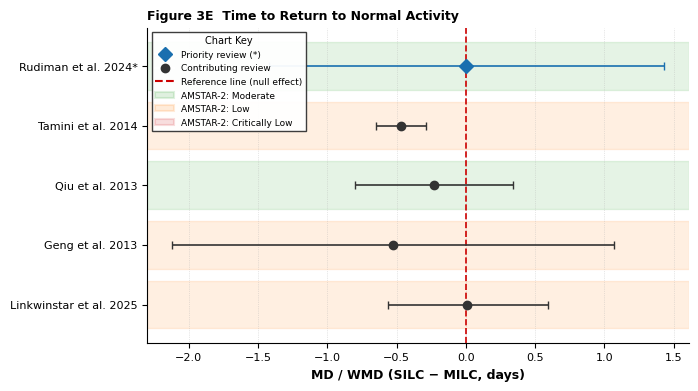

Saved → Figure3E_Return_Activity.tiff


In [84]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 3E — Time to Return to Normal Activity (MD / WMD, days)            ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig3e = pd.DataFrame([
    ('Rudiman et al.',    2024,  0.00, -1.42,  1.43, 'Moderate', True ),  # priority
    ('Tamini et al.',     2014, -0.47, -0.65, -0.29, 'Low',      False),
    ('Qiu et al.',        2013, -0.23, -0.80,  0.34, 'Moderate', False),
    ('Geng et al.',       2013, -0.527,-2.122,  1.068,'Low',     False),
    ('Linkwinstar et al.',2025,  0.01, -0.56,  0.59, 'Low',      False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig3e['no_ci'] = False

fig, ax = plt.subplots(figsize=(FIG_W_IN, fig_height(len(fig3e) + 1)))
draw_forest_panel(
    ax, fig3e,
    x_label='MD / WMD (SILC − MILC, days)',
    title='Time to Return to Normal Activity',
    panel_tag='Figure 3E'
)

# Add graphical key as inset in first panel only
add_inset_key(ax, position='upper left')


plt.tight_layout()
plt.savefig('Figure3E_Return_Activity.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure3E_Return_Activity.tiff')

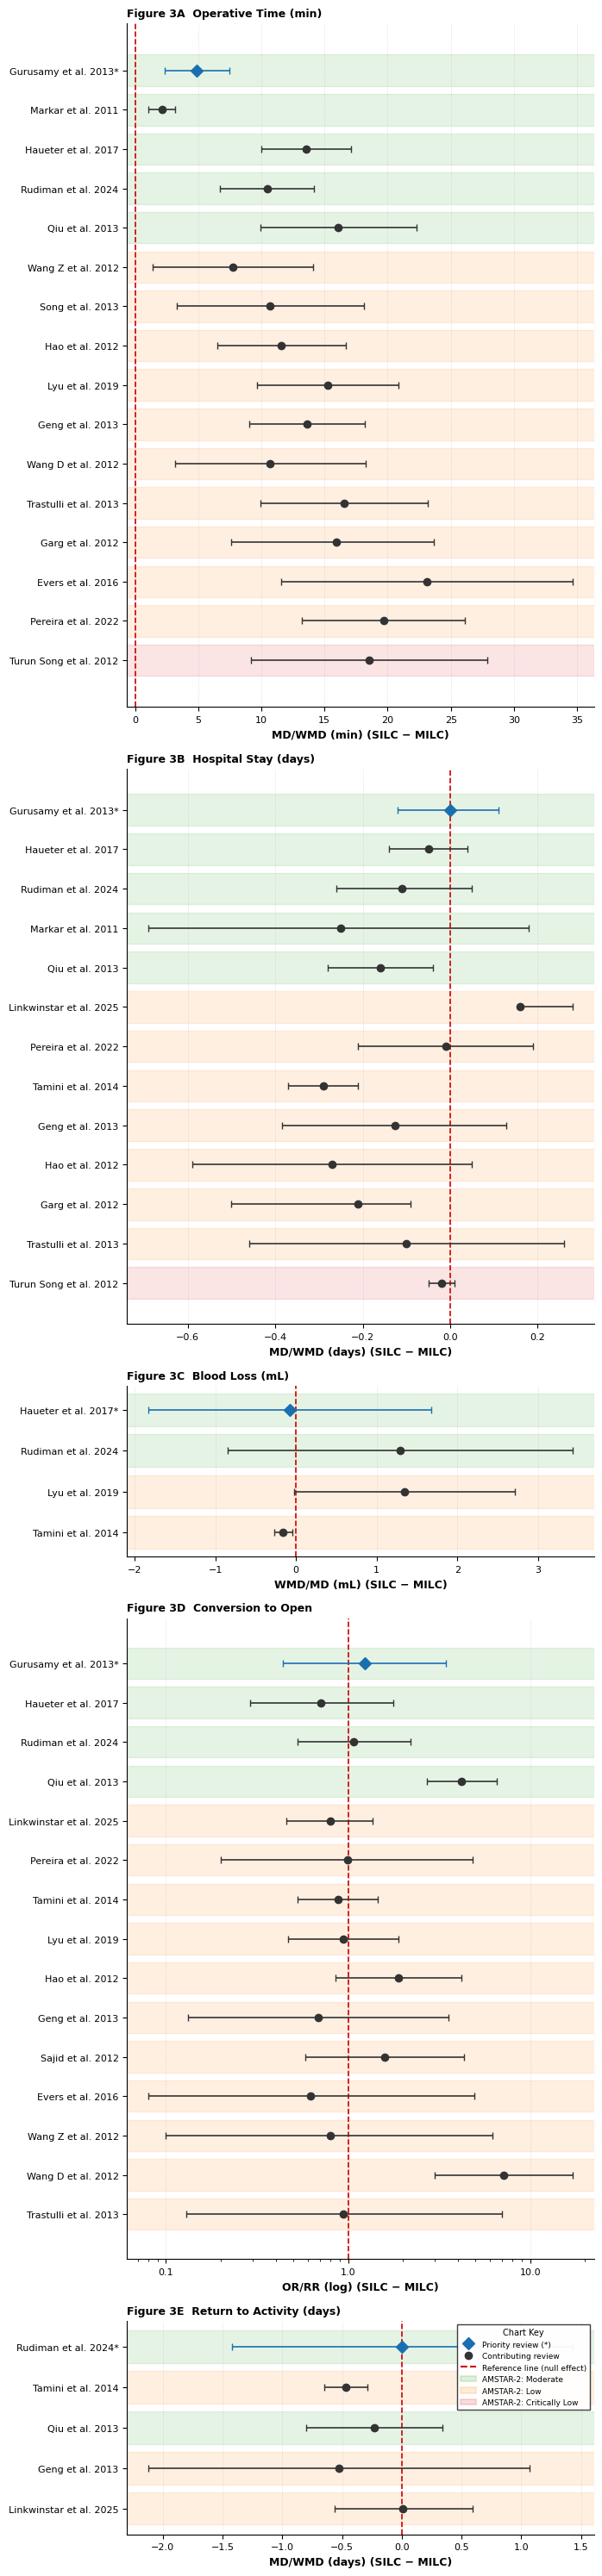

Saved → Figure3_Surgical_Efficacy.tiff  ← this is the Figure 1_Surgical Efficacy.tiff


In [85]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 3 — COMBINED (5-panel surgical efficacy)                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# For the combined view we use MD/WMD panels for 3A/3B/3C/3E and log for 3D
panel_specs_fig3 = [
    (fig3a,    'Figure 3A', 'Operative Time (min)',         'MD/WMD (min)',   False, 0),
    (fig3b_md, 'Figure 3B', 'Hospital Stay (days)',         'MD/WMD (days)',  False, 0),
    (fig3c,    'Figure 3C', 'Blood Loss (mL)',              'WMD/MD (mL)',    False, 0),
    (fig3d,    'Figure 3D', 'Conversion to Open',          'OR/RR (log)',    True,  1),
    (fig3e,    'Figure 3E', 'Return to Activity (days)',    'MD/WMD (days)',  False, 0),
]

row_counts_3 = [len(d) for d, *_ in panel_specs_fig3]
fig, axes = plt.subplots(
    5, 1,
    figsize=(FIG_W_IN, fig_height(sum(row_counts_3) + 8)),
    gridspec_kw={'height_ratios': row_counts_3}
)

for ax, (df, tag, title, xlabel, logscale, ref) in zip(axes, panel_specs_fig3):
    draw_forest_panel(ax, df,
        x_label=f'{xlabel} (SILC − MILC)',
        title=title, panel_tag=tag,
        log_scale=logscale, ref_line=ref)

# Add graphical key as inset in first panel only
add_inset_key(ax, position='upper right')

plt.tight_layout()
plt.savefig('Figure3_Surgical_Efficacy.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure3_Surgical_Efficacy.tiff  ← this is the Figure 1_Surgical Efficacy.tiff')

---
## Figure 4 — Surgical Safety Outcomes
Six panels: 4A Wound Infection, 4B Bile Duct Injury, 4C Bile Leakage, 4D Incisional Hernia, 4E Haematoma, 4F Retained Bile Stones

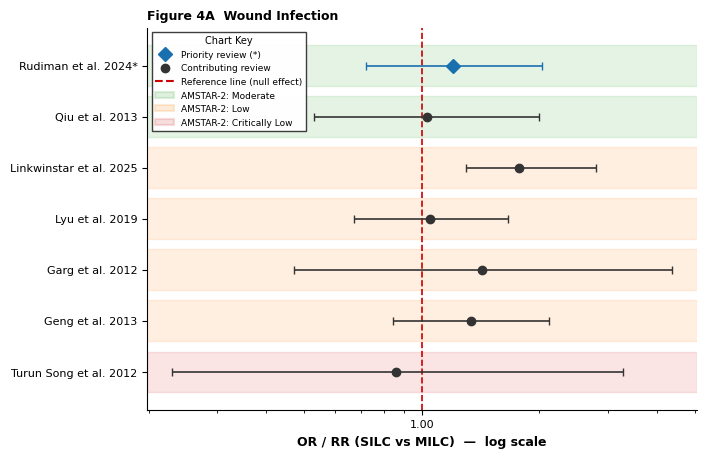

Saved → Figure4A_Wound_Infection.tiff


In [86]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 4A — Wound Infection (OR/RR — LOG SCALE)                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig4a = pd.DataFrame([
    ('Rudiman et al.',    2024, 1.20, 0.72, 2.03, 'Moderate',      True ),  # priority RR
    ('Qiu et al.',        2013, 1.03, 0.53, 2.00, 'Moderate',      False),  # OR
    ('Linkwinstar et al.',2025, 1.77, 1.30, 2.79, 'Low',           False),  # OR
    ('Lyu et al.',        2019, 1.05, 0.67, 1.66, 'Low',           False),  # RR
    ('Garg et al.',       2012, 1.43, 0.47, 4.36, 'Low',           False),  # RR
    ('Geng et al.',       2013, 1.336,0.842,2.119,'Low',           False),  # OR
    ('Turun Song et al.', 2012, 0.86, 0.23, 3.27, 'Critically Low',False),  # OR
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig4a['no_ci'] = False

fig, ax = plt.subplots(figsize=(FIG_W_IN, fig_height(len(fig4a) + 1)))
draw_forest_panel(ax, fig4a,
    x_label='OR / RR (SILC vs MILC)  —  log scale',
    title='Wound Infection', panel_tag='Figure 4A',
    ref_line=1, log_scale=True)

# Add graphical key as inset in first panel only
add_inset_key(ax, position='upper left')

plt.savefig('Figure4A_Wound_Infection.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure4A_Wound_Infection.tiff')

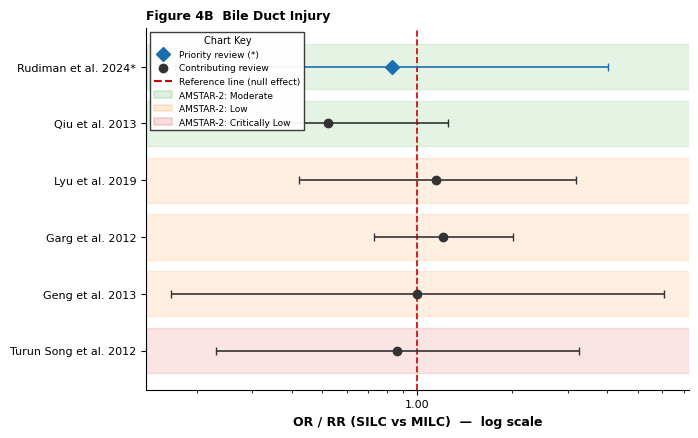

Saved → Figure4B_Bile_Duct.tiff


In [87]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 4B — Bile Duct Injury (OR/RR — LOG SCALE)                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig4b = pd.DataFrame([
    ('Rudiman et al.',    2024, 0.83, 0.17, 4.04,  'Moderate',      True ),
    ('Qiu et al.',        2013, 0.52, 0.22, 1.25,  'Moderate',      False),
    ('Lyu et al.',        2019, 1.15, 0.42, 3.19,  'Low',           False),
    ('Garg et al.',       2012, 1.21, 0.73, 2.01,  'Low',           False),
    ('Geng et al.',       2013, 1.000,0.165,6.066, 'Low',           False),
    ('Turun Song et al.', 2012, 0.86, 0.23, 3.27,  'Critically Low',False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig4b['no_ci'] = False

fig, ax = plt.subplots(figsize=(FIG_W_IN, fig_height(len(fig4b) + 1)))
draw_forest_panel(ax, fig4b,
    x_label='OR / RR (SILC vs MILC)  —  log scale',
    title='Bile Duct Injury', panel_tag='Figure 4B',
    ref_line=1, log_scale=True)

# Add graphical key as inset in first panel only
add_inset_key(ax, position='upper left')

plt.tight_layout()
plt.savefig('Figure4B_Bile_Duct.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure4B_Bile_Duct.tiff')

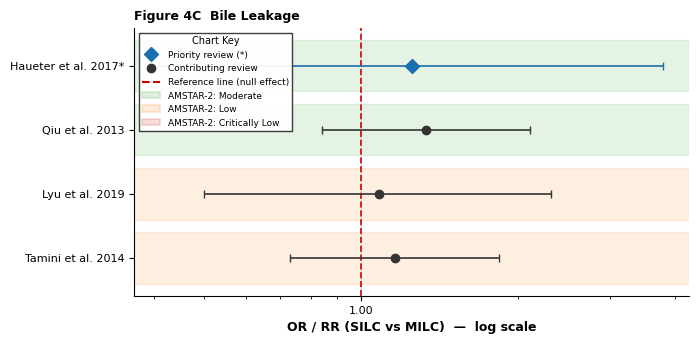

Saved → Figure4C_Bile_Leakage.tiff


In [88]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 4C — Bile Leakage (OR/RR — LOG SCALE)                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig4c = pd.DataFrame([
    ('Haueter et al.',  2017, 1.25, 0.41, 3.80, 'Moderate', True ),
    ('Qiu et al.',      2013, 1.33, 0.84, 2.11, 'Moderate', False),
    ('Lyu et al.',      2019, 1.08, 0.50, 2.31, 'Low',      False),
    ('Tamini et al.',   2014, 1.16, 0.73, 1.84, 'Low',      False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig4c['no_ci'] = False

fig, ax = plt.subplots(figsize=(FIG_W_IN, fig_height(len(fig4c) + 1)))
draw_forest_panel(ax, fig4c,
    x_label='OR / RR (SILC vs MILC)  —  log scale',
    title='Bile Leakage', panel_tag='Figure 4C',
    ref_line=1, log_scale=True)

# Add graphical key as inset in first panel only
add_inset_key(ax, position='upper left')

plt.tight_layout()
plt.savefig('Figure4C_Bile_Leakage.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure4C_Bile_Leakage.tiff')

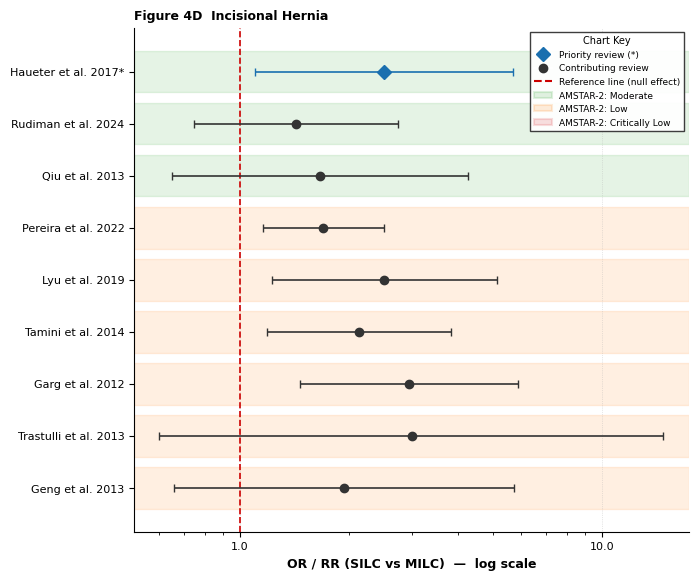

Saved → Figure4D_Incisional_Hernia.tiff


In [89]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 4D — Incisional Hernia (OR/RR — LOG SCALE)                        ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig4d = pd.DataFrame([
    ('Haueter et al.',   2017, 2.50, 1.10,  5.69,  'Moderate',      True ),
    ('Rudiman et al.',   2024, 1.43, 0.75,  2.74,  'Moderate',      False),
    ('Qiu et al.',       2013, 1.67, 0.65,  4.27,  'Moderate',      False),
    ('Pereira et al.',   2022, 1.70, 1.16,  2.50,  'Low',           False),
    ('Lyu et al.',       2019, 2.51, 1.23,  5.12,  'Low',           False),
    ('Tamini et al.',    2014, 2.133,1.19,  3.83,  'Low',           False),
    ('Garg et al.',      2012, 2.94, np.nan,np.nan,'Low',           False),  # CI NR
    ('Trastulli et al.', 2013, 2.99, 0.60, 14.80,  'Low',           False),
    ('Geng et al.',      2013, 1.937,0.658, 5.706, 'Low',           False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
# Garg: no CI — placeholder on log scale
fig4d['no_ci'] = fig4d['CI_Low'].isna()
fig4d['CI_Low']  = fig4d['CI_Low'].fillna(fig4d['Effect'] / 2.0)
fig4d['CI_High'] = fig4d['CI_High'].fillna(fig4d['Effect'] * 2.0)

fig, ax = plt.subplots(figsize=(FIG_W_IN, fig_height(len(fig4d) + 1)))
draw_forest_panel(ax, fig4d,
    x_label='OR / RR (SILC vs MILC)  —  log scale',
    title='Incisional Hernia', panel_tag='Figure 4D',
    ref_line=1, log_scale=True)


# Add graphical key as inset in first panel only
add_inset_key(ax, position='upper right')

plt.tight_layout()
plt.savefig('Figure4D_Incisional_Hernia.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure4D_Incisional_Hernia.tiff')

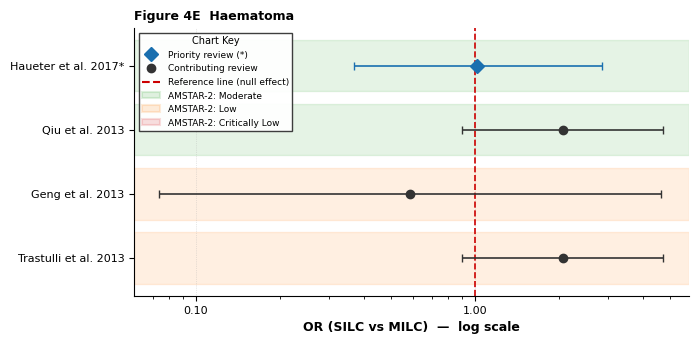

Saved → Figure4E_Haematoma.tiff


In [90]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 4E — Haematoma (OR — LOG SCALE)                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig4e = pd.DataFrame([
    ('Haueter et al.',   2017, 1.02, 0.37, 2.86,  'Moderate', True ),
    ('Qiu et al.',       2013, 2.07, 0.90, 4.74,  'Moderate', False),
    ('Geng et al.',      2013, 0.586,0.074,4.639, 'Low',      False),
    ('Trastulli et al.', 2013, 2.07, 0.90, 4.74,  'Low',      False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig4e['no_ci'] = False

fig, ax = plt.subplots(figsize=(FIG_W_IN, fig_height(len(fig4e) + 1)))
draw_forest_panel(ax, fig4e,
    x_label='OR (SILC vs MILC)  —  log scale',
    title='Haematoma', panel_tag='Figure 4E',
    ref_line=1, log_scale=True)

# Add graphical key as inset in first panel only
add_inset_key(ax, position='upper left')

plt.tight_layout()
plt.savefig('Figure4E_Haematoma.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure4E_Haematoma.tiff')

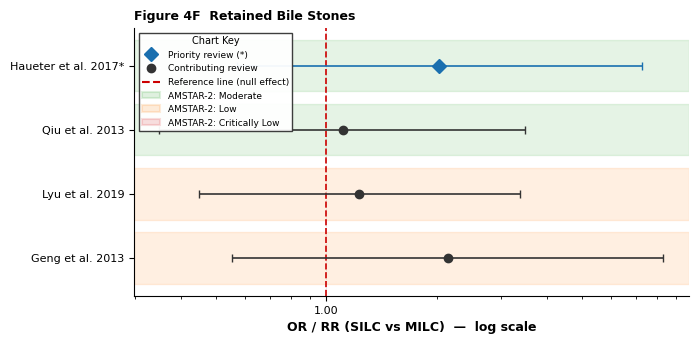

Saved → Figure4F_Retained_Stones.tiff


In [91]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 4F — Retained Bile Stones (OR/RR — LOG SCALE)                     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

fig4f = pd.DataFrame([
    ('Haueter et al.', 2017, 2.03, 0.57, 7.27,  'Moderate', True ),
    ('Qiu et al.',     2013, 1.11, 0.35, 3.49,  'Moderate', False),
    ('Lyu et al.',     2019, 1.23, 0.45, 3.39,  'Low',      False),
    ('Geng et al.',    2013, 2.149,0.554,8.329, 'Low',      False),
], columns=['Author','Year','Effect','CI_Low','CI_High','AMSTAR2','Priority'])
fig4f['no_ci'] = False

fig, ax = plt.subplots(figsize=(FIG_W_IN, fig_height(len(fig4f) + 1)))
draw_forest_panel(ax, fig4f,
    x_label='OR / RR (SILC vs MILC)  —  log scale',
    title='Retained Bile Stones', panel_tag='Figure 4F',
    ref_line=1, log_scale=True)

# Add graphical key as inset in first panel only
add_inset_key(ax, position='upper left')

plt.tight_layout()
plt.savefig('Figure4F_Retained_Stones.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure4F_Retained_Stones.tiff')

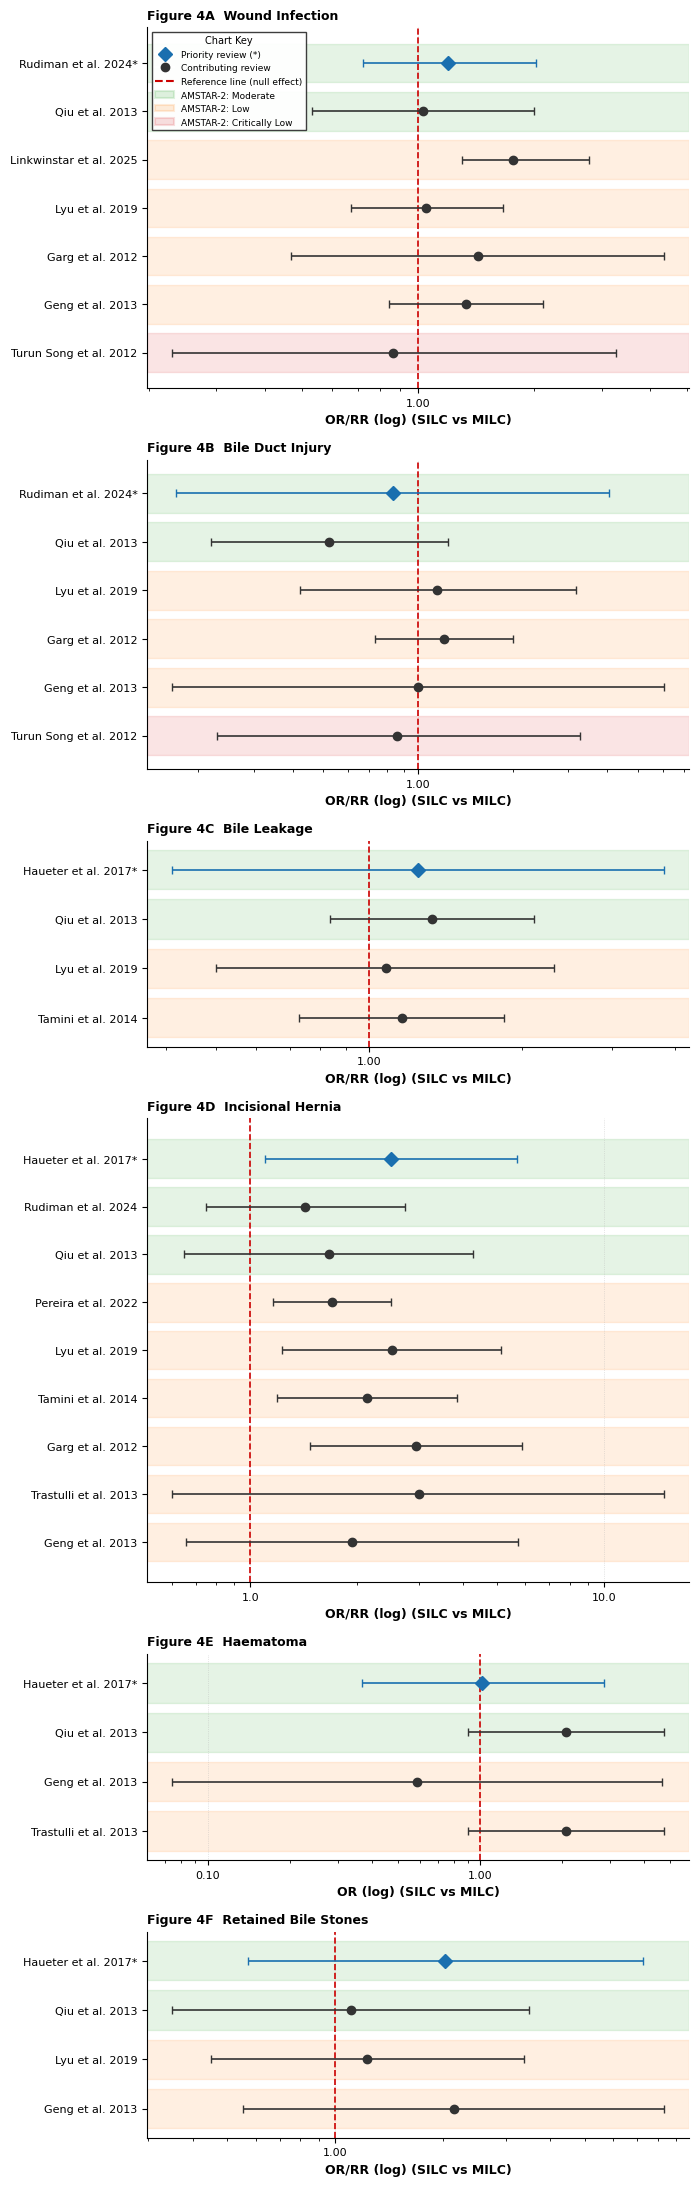

Saved → Figure4_Safety_Outcomes.tiff  ← this is the Figure 3_Safety Outcomes.tiff


In [92]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  FIGURE 4 — COMBINED (6-panel surgical safety)                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

panel_specs_fig4 = [
    (fig4a, 'Figure 4A', 'Wound Infection',       'OR/RR (log)', True, 1),
    (fig4b, 'Figure 4B', 'Bile Duct Injury',      'OR/RR (log)', True, 1),
    (fig4c, 'Figure 4C', 'Bile Leakage',          'OR/RR (log)', True, 1),
    (fig4d, 'Figure 4D', 'Incisional Hernia',     'OR/RR (log)', True, 1),
    (fig4e, 'Figure 4E', 'Haematoma',             'OR (log)',    True, 1),
    (fig4f, 'Figure 4F', 'Retained Bile Stones',  'OR/RR (log)', True, 1),
]

row_counts_4 = [len(d) for d, *_ in panel_specs_fig4]
fig, axes = plt.subplots(
    6, 1,
    figsize=(FIG_W_IN, fig_height(sum(row_counts_4) + 10)),
    gridspec_kw={'height_ratios': row_counts_4}
)

for ax, (df, tag, title, xlabel, logscale, ref) in zip(axes, panel_specs_fig4):
    draw_forest_panel(ax, df,
        x_label=f'{xlabel} (SILC vs MILC)',
        title=title, panel_tag=tag,
        log_scale=logscale, ref_line=ref)

# Add graphical key as inset in first panel only
add_inset_key(axes[0], position='upper left')


plt.tight_layout()
plt.savefig('Figure4_Safety_Outcomes.tiff', dpi=DPI, bbox_inches='tight', format='tiff')
plt.show()
print('Saved → Figure4_Safety_Outcomes.tiff  ← this is the Figure 3_Safety Outcomes.tiff')

---
## Output File Summary

| File | Description |
|------|-------------|
| `Figure2_Patient_Reported.tiff` | Combined 4-panel (Figure 2 — Patient-Reported) |
| `Figure2A_Pain_Early.tiff` | Standalone Figure 2A with SMD sub-panel |
| `Figure2B_Pain_Late.tiff` | Standalone Figure 2B with SMD sub-panel |
| `Figure2C_Cosmetic.tiff` | Standalone Figure 2C with SMD sub-panel |
| `Figure2D_Analgesic.tiff` | Standalone Figure 2D |
| `Figure3_Surgical_Efficacy.tiff` | Combined 5-panel (Figure 3 — Surgical Efficacy) |
| `Figure3A_Operative_Time.tiff` | Standalone Figure 3A |
| `Figure3B_Hospital_Stay.tiff` | Standalone Figure 3B with SMD sub-panel |
| `Figure3C_Blood_Loss.tiff` | Standalone Figure 3C |
| `Figure3D_Conversion.tiff` | Standalone Figure 3D (log scale) |
| `Figure3E_Return_Activity.tiff` | Standalone Figure 3E |
| `Figure4_Safety_Outcomes.tiff` | Combined 6-panel (Figure 4 — Safety) |
| `Figure4A_Wound_Infection.tiff` | Standalone Figure 4A |
| `Figure4B_Bile_Duct.tiff` | Standalone Figure 4B |
| `Figure4C_Bile_Leakage.tiff` | Standalone Figure 4C |
| `Figure4D_Incisional_Hernia.tiff` | Standalone Figure 4D |
| `Figure4E_Haematoma.tiff` | Standalone Figure 4E |
| `Figure4F_Retained_Stones.tiff` | Standalone Figure 4F |

### Key Design Decisions
1. **No pooled estimates or diamonds** — umbrella review design precludes re-pooling.
2. **No weights** — meaningless without pooling.
3. **SMD sub-panels** — drawn separately wherever the same outcome has both MD/WMD and SMD reviews (2A, 2B, 2C, 3B).
4. **Priority review** — marked with `*` and blue diamond (`D`) marker.
5. **AMSTAR-2 labels** — colour-coded (green/orange/red) to the left of each row.
6. **NR CI handling** — studies not reporting a CI are flagged with `no_ci=True`; a symmetric placeholder is used *for display only* and is disclosed in the figure legend.
7. **Dichotomous outcomes** — plotted on log scale with reference at 1.
8. **Output** — TIFF at 300 DPI, 18 cm wide (BMC Surgery specification).

---
## Figure Legend & Key Reference
### For manuscript inclusion (max 300 words)

**Forest Plot Graphical Elements:**

| Element | Meaning |
|---------|---------|
| **Blue diamond ◇** | Meta-analysis designated as priority review for this outcome |
| **Circle ○** | Contributing meta-analysis (not priority) |
| **Horizontal line** | 95% confidence interval (CI) for effect estimate |
| **Vertical marker** | Point estimate (mean effect or ratio) |
| **Red dashed line** | Reference line (0 for continuous outcomes; 1 for OR/RR on log scale) |
| **Crossing CI with reference** | Effect estimate CIs crossing reference line → no statistical difference |

**AMSTAR-2 Quality Rating (Row Background Shading):**

The background color of each study row indicates its quality rating:

| Color | Rating | Interpretation |
|-------|--------|-----------------|
| **Green shading** | Moderate | Likely free from bias; high confidence in results |
| **Orange shading** | Low | May be biased; moderate confidence in results |
| **Red shading** | Critically Low | Likely biased; low confidence in results |

**Metric Types:**
- **MD/WMD**: Mean difference or weighted mean difference (continuous, unit-specific)
- **SMD**: Standardized mean difference (continuous, pooled across different measurement scales)
- **OR/RR**: Odds ratio / risk ratio (dichotomous outcomes, plotted on log scale for clarity)

**Reporting Details:**
- Plot includes only studies with reported 95% confidence intervals, except where noted in individual figure legends.
- Studies not reporting CIs receive a symmetric placeholder interval (notation: `NR` for not reported).
- Placeholder intervals on log scales use ×2/÷2 multiplier for display purposes only.
- Asterisk (*) in author label indicates priority review designation for that outcome.
- SMD sub-panels separated from MD/WMD panels where outcomes measured by multiple scale types.

**Umbrella Review Context:**
This is a systematic umbrella review of meta-analyses; no re-pooled summary estimate or diamond is displayed. Each row represents one contributing meta-analysis. Vertical reference lines indicate the null hypothesis (no difference between SILC and MILC).

**Chart Key Integration:**
All legend elements (markers, reference lines, and AMSTAR-2 quality shadings) are presented as an inset graphical key in the first panel of each figure for clarity and professional presentation.